# Bayesian Optimisation — Final Thesis Run (20 Epochs) | Fitness 60/40

**Bachelor Thesis — Differential Privacy for Medical Data**  
**German University in Cairo | Media Engineering Technology**

This is the **60/40 fitness variant** of the final BO run.
**Fitness = 60% AUROC + 40% privacy_score** (vs 70/30 in the baseline run).

### What changed from the exploratory run:

| Setting | Exploratory Run | This Final Run | Reason |
|---|---|---|---|
| Epochs per trial | 3 | **20** | Proper model convergence |
| Search range | [0.5, 20] | **[0.5, 3.0]** | Consensus from all 5 methods: optimal ε ∈ [0.79, 1.21] |
| N_TRIALS | 12 | **8** | Narrower range → fewer trials needed |
| Validation fold | 9 | **9** (search) | Fold 9 = validation during BO search (correct) |
| Final evaluation | Fold 9 | **Fold 10** | PTB-XL standard test fold — never seen during search |

### Why fold 9 for search and fold 10 for final result?
Using fold 10 during the search would be data leakage — you would be selecting epsilon based on the test set.  
The correct protocol: **search on fold 9 (validation) → report on fold 10 (test)**.

### Estimated runtime on Kaggle T4 x2:
- Each trial: ~20 epochs × ~1.5 min/epoch ≈ **30 min per trial**
- 8 trials: ~4 hours for the BO search
- Final evaluation (fold 10): +30 min
- **Total estimated: 4–5 hours**

### Setup on Kaggle:
1. Add **PTB-XL dataset** (khyeh0719) as input
2. Set accelerator to **GPU T4 x2**
3. Run All — do not run individual cells

## Cell 1 — Install Dependencies

In [7]:
!pip install opacus==1.4.0 optuna wfdb --quiet

## Cell 2 — Imports & Configuration

In [8]:
import os
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

from sklearn.metrics import roc_auc_score

import wfdb
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from opacus import PrivacyEngine
from opacus.utils.batch_memory_manager import BatchMemoryManager

warnings.filterwarnings('ignore')

# ─── PATHS ────────────────────────────────────────────────────────────────────
DATA_PATH   = "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"
RESULTS_DIR = "/kaggle/working/bo_final_results_60_40"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ─── MODEL / TRAINING SETTINGS ───────────────────────────────────────────────
DELTA         = 1e-5
MAX_GRAD_NORM = 1.0
EPOCHS        = 20      # ← INCREASED from 3 — proper model convergence
BATCH_SIZE    = 32
MAX_PHY_BATCH = 32
LR            = 1e-3
N_CLASSES     = 5
SEED          = 42

# ─── COMPOSITE FITNESS SETTINGS ──────────────────────────────────────────────
PRIVACY_WEIGHT = 0.4    # 40% privacy, 60% AUROC
EPS_SCALE      = 20.0   # privacy_score = 1 - epsilon / EPS_SCALE

# ─── BAYESIAN OPTIMISATION SETTINGS ──────────────────────────────────────────
N_TRIALS   = 8          # ← REDUCED from 12 (narrower search → fewer needed)
N_STARTUP  = 3          # Random trials before TPE model activates
EPS_MIN    = 0.5        # Search range narrowed: all 5 methods agree ε ∈ [0.79, 1.21]
EPS_MAX    = 3.0        # ← NARROWED from 20.0

# ─── FOLD SETTINGS ───────────────────────────────────────────────────────────
TRAIN_FOLDS = list(range(1, 9))   # Folds 1–8 = training
VAL_FOLD    = 9                    # Fold 9  = validation during BO search
TEST_FOLD   = 10                   # Fold 10 = standard PTB-XL test set (final report only)

# ─── REFERENCE VALUES FROM PREVIOUS RUNS ─────────────────────────────────────
BASELINE_AUROC = 0.9318  # No-DP baseline (from epsilon sweep)
PREV_BO_EPS    = 0.8056  # Best epsilon from exploratory run
CONSENSUS_EPS  = 0.87    # Mean of all 5 methods: BO(0.81), SA(0.87), GA(1.11), PSO(1.20), NSGA(0.80)

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device       : {DEVICE}")
print(f"Epochs/trial : {EPOCHS}  (was 3 in exploratory run)")
print(f"N_TRIALS     : {N_TRIALS} ({N_STARTUP} random + {N_TRIALS - N_STARTUP} TPE-guided)")
print(f"Search range : ε ∈ [{EPS_MIN}, {EPS_MAX}]  (narrowed from [0.5, 20])")
print(f"Val fold     : {VAL_FOLD}  (used during search)")
print(f"Test fold    : {TEST_FOLD}  (reported at the end — never seen during search)")
print(f"Est. runtime : ~{N_TRIALS * EPOCHS * 1.5 / 60:.1f}–{N_TRIALS * EPOCHS * 2.0 / 60:.1f} hours for search + ~{EPOCHS * 1.5 / 60:.0f}–{EPOCHS * 2.0 / 60:.0f} min for final eval")

Device       : cuda
Epochs/trial : 20  (was 3 in exploratory run)
N_TRIALS     : 8 (3 random + 5 TPE-guided)
Search range : ε ∈ [0.5, 3.0]  (narrowed from [0.5, 20])
Val fold     : 9  (used during search)
Test fold    : 10  (reported at the end — never seen during search)
Est. runtime : ~4.0–5.3 hours for search + ~0–1 min for final eval


## Cell 3 — Load PTB-XL Metadata

In [9]:
import ast

ptbxl_db  = pd.read_csv(os.path.join(DATA_PATH, 'ptbxl_database.csv'), index_col='ecg_id')
scp_codes = pd.read_csv(os.path.join(DATA_PATH, 'scp_statements.csv'), index_col=0)
ptbxl_db['scp_codes'] = ptbxl_db['scp_codes'].apply(ast.literal_eval)
scp_codes = scp_codes[scp_codes['diagnostic'] == 1.0]

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

def get_superclass_labels(scp_dict):
    labels = np.zeros(N_CLASSES, dtype=np.float32)
    for code, likelihood in scp_dict.items():
        if likelihood >= 100 and code in scp_codes.index:
            superclass = scp_codes.loc[code, 'diagnostic_class']
            if superclass in SUPERCLASSES:
                labels[SUPERCLASSES.index(superclass)] = 1.0
    return labels

ptbxl_db['label_vec'] = ptbxl_db['scp_codes'].apply(get_superclass_labels)
ptbxl_db = ptbxl_db[ptbxl_db['label_vec'].apply(lambda x: x.sum() > 0)].copy()

train_df = ptbxl_db[ptbxl_db['strat_fold'].isin(TRAIN_FOLDS)].copy()
val_df   = ptbxl_db[ptbxl_db['strat_fold'] == VAL_FOLD].copy()
test_df  = ptbxl_db[ptbxl_db['strat_fold'] == TEST_FOLD].copy()

print(f"Train (folds 1–8): {len(train_df)} records")
print(f"Val   (fold {VAL_FOLD}):    {len(val_df)} records  ← used during BO search")
print(f"Test  (fold {TEST_FOLD}):   {len(test_df)} records  ← final thesis result only")

Train (folds 1–8): 13826 records
Val   (fold 9):    1717 records  ← used during BO search
Test  (fold 10):   1716 records  ← final thesis result only


## Cell 4 — Shared Utilities (Dataset, Model, Evaluate)

In [10]:
class ECGDataset(Dataset):
    def __init__(self, df, data_root, sampling_freq=100):
        self.df = df.reset_index(drop=True)
        self.data_root = data_root
        self.freq_col  = 'filename_lr' if sampling_freq == 100 else 'filename_hr'

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        fpath  = os.path.join(self.data_root, row[self.freq_col])
        record = wfdb.rdrecord(fpath)
        signal = record.p_signal.T
        signal = np.nan_to_num(signal, nan=0.0)
        mean   = signal.mean(axis=1, keepdims=True)
        std    = signal.std(axis=1, keepdims=True) + 1e-8
        signal = ((signal - mean) / std)[np.newaxis, :, :].astype(np.float32)
        return torch.from_numpy(signal), torch.from_numpy(row['label_vec'].astype(np.float32))


def make_loaders(train_df, val_df, test_df, data_root, batch_size=32):
    train_loader = DataLoader(ECGDataset(train_df, data_root), batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(ECGDataset(val_df,   data_root), batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ECGDataset(test_df,  data_root), batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader


def replace_batchnorm(module):
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            num_channels = child.num_features
            num_groups   = 32
            while num_channels % num_groups != 0:
                num_groups //= 2
            setattr(module, name, nn.GroupNorm(num_groups, num_channels))
        else:
            replace_batchnorm(child)
    return module


def build_model():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=(7,7), stride=(2,2), padding=(3,3), bias=False)
    model.fc    = nn.Linear(model.fc.in_features, N_CLASSES)
    return replace_batchnorm(model)


def evaluate(model, loader, criterion, device):
    model.eval()
    all_logits, all_labels, total_loss = [], [], 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y   = x.to(device), y.to(device)
            logits = model(x)
            total_loss += criterion(logits, y).item() * x.size(0)
            all_logits.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(y.cpu().numpy())
    preds  = np.vstack(all_logits)
    labels = np.vstack(all_labels)
    return (total_loss / len(loader.dataset),
            roc_auc_score(labels, preds, average='macro'),
            roc_auc_score(labels, preds, average='micro'))


print("Utilities loaded.")
print("BatchNorm → GroupNorm replacement active (required for DP-SGD compatibility)")

Utilities loaded.
BatchNorm → GroupNorm replacement active (required for DP-SGD compatibility)


## Cell 5 — Optuna Objective Function

Same composite fitness formula as all other methods:  
`fitness = 0.6 × AUROC + 0.4 × privacy_score`  
`privacy_score = 1 − ε / 20.0`

Evaluated on **fold 9 (validation)** during search. Fold 10 is held out for the final result.

**Checkpoint / resume:** After every trial, results are saved to `bo_final_trial_log.csv`  
and the Optuna study is persisted to `optuna_study.db`.  
If the kernel dies, simply **Run All** again — it will resume from the last completed trial.

In [11]:
# ─── Persistence: load existing trial log if resuming ────────────────────────
CSV_LOG_PATH = os.path.join(RESULTS_DIR, 'bo_final_trial_log.csv')
if os.path.exists(CSV_LOG_PATH):
    _existing = pd.read_csv(CSV_LOG_PATH)
    trial_log = _existing.to_dict('records')
    print(f"RESUMED: loaded {len(trial_log)} completed trials from CSV")
else:
    trial_log = []
    print("Fresh run: no existing trial log found")

search_start = time.time()

def objective(trial):
    epsilon = trial.suggest_float('epsilon', EPS_MIN, EPS_MAX, log=True)
    phase   = 'random' if trial.number < N_STARTUP else 'TPE-guided'
    t_start = time.time()

    elapsed_total = (t_start - search_start) / 60
    print(f'\n  Trial {trial.number + 1}/{N_TRIALS} [{phase}] | ε = {epsilon:.4f} | Elapsed: {elapsed_total:.1f} min')

    torch.cuda.empty_cache()
    gc.collect()

    train_loader, val_loader, _ = make_loaders(train_df, val_df, test_df, DATA_PATH, BATCH_SIZE)
    model     = build_model().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    privacy_engine = PrivacyEngine(accountant='rdp')
    model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
        module=model, optimizer=optimizer, data_loader=train_loader,
        target_epsilon=epsilon, target_delta=DELTA,
        epochs=EPOCHS, max_grad_norm=MAX_GRAD_NORM,
    )

    for epoch in range(1, EPOCHS + 1):
        model.train()
        with BatchMemoryManager(data_loader=train_loader,
                                max_physical_batch_size=MAX_PHY_BATCH,
                                optimizer=optimizer) as safe_loader:
            for x, y in safe_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                optimizer.zero_grad()
                criterion(model(x), y).backward()
                optimizer.step()
        achieved_eps = privacy_engine.get_epsilon(DELTA)
        _, _, val_auroc = evaluate(model, val_loader, criterion, DEVICE)
        ep_time = (time.time() - t_start) / 60
        print(f'    Epoch {epoch:2d}/{EPOCHS} | Val AUROC: {val_auroc:.4f} | ε achieved: {achieved_eps:.3f} | {ep_time:.1f} min elapsed')

    _, _, final_auroc = evaluate(model, val_loader, criterion, DEVICE)
    privacy_score   = 1.0 - (epsilon / EPS_SCALE)
    composite_score = (1 - PRIVACY_WEIGHT) * final_auroc + PRIVACY_WEIGHT * privacy_score
    trial_time      = (time.time() - t_start) / 60

    print(f'  → Trial {trial.number + 1} done in {trial_time:.1f} min: ε={epsilon:.4f} | AUROC={final_auroc:.4f} | Privacy={privacy_score:.4f} | Fitness={composite_score:.4f}')

    trial_log.append({
        'trial':          trial.number + 1,
        'epsilon':        epsilon,
        'auroc':          final_auroc,
        'fitness':        composite_score,
        'privacy_score':  privacy_score,
        'phase':          phase,
        'trial_time_min': round(trial_time, 1),
    })

    # ── Save after EVERY trial so progress survives a crash ──────────────────
    pd.DataFrame(trial_log).to_csv(CSV_LOG_PATH, index=False)
    print(f'  ✓ Checkpoint saved ({len(trial_log)}/{N_TRIALS} trials complete)')

    del model, optimizer, privacy_engine
    torch.cuda.empty_cache()
    gc.collect()

    return composite_score


print('Objective function ready.')
print(f'  Fitness formula : {int((1-PRIVACY_WEIGHT)*100)}% × AUROC + {int(PRIVACY_WEIGHT*100)}% × (1 − ε/20)')
print(f'  Evaluation fold : {VAL_FOLD} (validation — fold {TEST_FOLD} held out for final test)')
print(f'  Checkpoint file : {CSV_LOG_PATH}')

Fresh run: no existing trial log found
Objective function ready.
  Fitness formula : 60% × AUROC + 40% × (1 − ε/20)
  Evaluation fold : 9 (validation — fold 10 held out for final test)
  Checkpoint file : /kaggle/working/bo_final_results_60_40/bo_final_trial_log.csv


## Cell 6 — Run Bayesian Optimisation Search

> **⏱ Estimated time: 4–5 hours** on Kaggle T4 x2  
> 8 trials × 20 epochs × ~1.5–2 min/epoch ≈ 240–320 min  
> Actual per-trial time will be printed as each trial completes.

**If interrupted:** Just click **Run All** again. The notebook detects completed trials  
from `optuna_study.db` and `bo_final_trial_log.csv` and picks up where it left off.  
You will NOT lose completed trials.

The search is over the **narrowed range ε ∈ [0.5, 3.0]** because all 5 previous methods  
confirmed the optimum is in this region. This saves ~2 hours vs. searching [0.5, 20].

In [12]:
import optuna.storages

DB_PATH  = os.path.join(RESULTS_DIR, 'optuna_study.db')
STORAGE  = f'sqlite:///{DB_PATH}'

print('Starting Bayesian Optimisation — Final Thesis Run')
print('='*60)
print(f'Search range : ε ∈ [{EPS_MIN}, {EPS_MAX}] (log-uniform)')
print(f'Epochs/trial : {EPOCHS}')
print(f'Trials       : {N_TRIALS} ({N_STARTUP} random + {N_TRIALS - N_STARTUP} TPE-guided)')
print(f'Fitness      : {int((1-PRIVACY_WEIGHT)*100)}% AUROC + {int(PRIVACY_WEIGHT*100)}% privacy')
print(f'Eval on      : Fold {VAL_FOLD} (validation)')
print(f'Checkpoint DB: {DB_PATH}')
print('='*60)

sampler = TPESampler(seed=SEED, n_startup_trials=N_STARTUP)
study   = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    study_name='dp_ecg_bo_60_40',
    storage=STORAGE,
    load_if_exists=True,          # ← resume if interrupted
)

completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
n_done      = len(completed)
n_remaining = N_TRIALS - n_done

if n_done > 0:
    print(f'RESUMED: {n_done} trials already complete, running {n_remaining} more')
else:
    print(f'Fresh run: running all {N_TRIALS} trials')

if n_remaining > 0:
    study.optimize(objective, n_trials=n_remaining, show_progress_bar=False)
else:
    print('All trials already complete — skipping search.')

# ─── Summary ─────────────────────────────────────────────────────────────────
best_trial   = study.best_trial
best_epsilon = best_trial.params['epsilon']
best_fitness = best_trial.value

# Match best trial to trial_log (by epsilon, robust to failed trial numbering)
best_log = min(trial_log, key=lambda t: abs(t['epsilon'] - best_epsilon))
best_auroc   = best_log['auroc']
best_privacy = best_log['privacy_score']

total_search_min = (time.time() - search_start) / 60

print(f'\n{"="*60}')
print(f' BO SEARCH COMPLETE')
print(f' Total search time  : {total_search_min:.1f} min ({total_search_min/60:.2f} hours)')
print(f' Optimal epsilon     : ε = {best_epsilon:.4f}')
print(f' AUROC (val fold 9)  : {best_auroc:.4f}')
print(f' Composite fitness   : {best_fitness:.4f}')
print(f' Privacy score       : {best_privacy:.4f}')
print(f'{"="*60}')
print(f'\n Previous exploratory run found: ε = {PREV_BO_EPS}')
print(f' This final run found:          ε = {best_epsilon:.4f}')
print(f' Difference: {abs(best_epsilon - PREV_BO_EPS):.4f} ε units')

Starting Bayesian Optimisation — Final Thesis Run
Search range : ε ∈ [0.5, 3.0] (log-uniform)
Epochs/trial : 20
Trials       : 8 (3 random + 5 TPE-guided)
Fitness      : 60% AUROC + 40% privacy
Eval on      : Fold 9 (validation)
Checkpoint DB: /kaggle/working/bo_final_results_60_40/optuna_study.db
Fresh run: running all 8 trials

  Trial 2/8 [random] | ε = 0.9782 | Elapsed: 0.0 min


04/24/2026 13:00:02:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


    Epoch  1/20 | Val AUROC: 0.7283 | ε achieved: 0.578 | 1.9 min elapsed
    Epoch  2/20 | Val AUROC: 0.7418 | ε achieved: 0.601 | 3.4 min elapsed
    Epoch  3/20 | Val AUROC: 0.7992 | ε achieved: 0.622 | 4.4 min elapsed
    Epoch  4/20 | Val AUROC: 0.8231 | ε achieved: 0.643 | 5.4 min elapsed
    Epoch  5/20 | Val AUROC: 0.8209 | ε achieved: 0.664 | 6.4 min elapsed
    Epoch  6/20 | Val AUROC: 0.8394 | ε achieved: 0.684 | 7.4 min elapsed
    Epoch  7/20 | Val AUROC: 0.8359 | ε achieved: 0.705 | 8.4 min elapsed
    Epoch  8/20 | Val AUROC: 0.8422 | ε achieved: 0.726 | 9.4 min elapsed
    Epoch  9/20 | Val AUROC: 0.8513 | ε achieved: 0.747 | 10.4 min elapsed
    Epoch 10/20 | Val AUROC: 0.8454 | ε achieved: 0.767 | 11.4 min elapsed
    Epoch 11/20 | Val AUROC: 0.8495 | ε achieved: 0.788 | 12.4 min elapsed
    Epoch 12/20 | Val AUROC: 0.8458 | ε achieved: 0.809 | 13.4 min elapsed
    Epoch 13/20 | Val AUROC: 0.8538 | ε achieved: 0.829 | 14.4 min elapsed
    Epoch 14/20 | Val AUROC: 0.85

04/24/2026 13:21:26:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


    Epoch  1/20 | Val AUROC: 0.7351 | ε achieved: 1.700 | 1.0 min elapsed
    Epoch  2/20 | Val AUROC: 0.8179 | ε achieved: 1.797 | 2.0 min elapsed
    Epoch  3/20 | Val AUROC: 0.8398 | ε achieved: 1.874 | 3.0 min elapsed
    Epoch  4/20 | Val AUROC: 0.8468 | ε achieved: 1.941 | 3.9 min elapsed
    Epoch  5/20 | Val AUROC: 0.8484 | ε achieved: 2.004 | 4.9 min elapsed
    Epoch  6/20 | Val AUROC: 0.8615 | ε achieved: 2.062 | 5.9 min elapsed
    Epoch  7/20 | Val AUROC: 0.8594 | ε achieved: 2.118 | 6.9 min elapsed
    Epoch  8/20 | Val AUROC: 0.8706 | ε achieved: 2.172 | 7.9 min elapsed
    Epoch  9/20 | Val AUROC: 0.8600 | ε achieved: 2.223 | 8.9 min elapsed
    Epoch 10/20 | Val AUROC: 0.8664 | ε achieved: 2.275 | 9.9 min elapsed
    Epoch 11/20 | Val AUROC: 0.8561 | ε achieved: 2.325 | 10.9 min elapsed
    Epoch 12/20 | Val AUROC: 0.8777 | ε achieved: 2.372 | 11.9 min elapsed
    Epoch 13/20 | Val AUROC: 0.8731 | ε achieved: 2.420 | 12.9 min elapsed
    Epoch 14/20 | Val AUROC: 0.8813

...

    Epoch  1/20 | Val AUROC: 0.7341 | ε achieved: 0.758 | 1.0 min elapsed
    Epoch  2/20 | Val AUROC: 0.7579 | ε achieved: 0.782 | 2.0 min elapsed
    Epoch  3/20 | Val AUROC: 0.8161 | ε achieved: 0.806 | 3.0 min elapsed
    Epoch  4/20 | Val AUROC: 0.8355 | ε achieved: 0.831 | 4.0 min elapsed
    Epoch  5/20 | Val AUROC: 0.8298 | ε achieved: 0.855 | 4.9 min elapsed
    Epoch  6/20 | Val AUROC: 0.8360 | ε achieved: 0.879 | 5.9 min elapsed
    Epoch  7/20 | Val AUROC: 0.8328 | ε achieved: 0.903 | 6.9 min elapsed
    Epoch  8/20 | Val AUROC: 0.8351 | ε achieved: 0.928 | 7.9 min elapsed
    Epoch  9/20 | Val AUROC: 0.8294 | ε achieved: 0.952 | 8.9 min elapsed
    Epoch 10/20 | Val AUROC: 0.8442 | ε achieved: 0.976 | 9.9 min elapsed
    Epoch 11/20 | Val AUROC: 0.8425 | ε achieved: 1.000 | 10.9 min elapsed
    Epoch 12/20 | Val AUROC: 0.8472 | ε achieved: 1.024 | 11.9 min elapsed
    Epoch 13/20 | Val AUROC: 0.8475 | ε achieved: 1.049 | 12.9 min elapsed
    Epoch 14/20 | Val AUROC: 0.8443

04/24/2026 15:02:01:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


    Epoch  1/20 | Val AUROC: 0.7220 | ε achieved: 0.207 | 1.0 min elapsed
    Epoch  2/20 | Val AUROC: 0.7114 | ε achieved: 0.225 | 2.0 min elapsed
    Epoch  3/20 | Val AUROC: 0.7188 | ε achieved: 0.242 | 3.0 min elapsed
    Epoch  4/20 | Val AUROC: 0.7224 | ε achieved: 0.258 | 4.0 min elapsed
    Epoch  5/20 | Val AUROC: 0.7380 | ε achieved: 0.275 | 4.9 min elapsed
    Epoch  6/20 | Val AUROC: 0.7497 | ε achieved: 0.291 | 6.0 min elapsed
    Epoch  7/20 | Val AUROC: 0.7731 | ε achieved: 0.308 | 7.0 min elapsed
    Epoch  8/20 | Val AUROC: 0.7994 | ε achieved: 0.324 | 7.9 min elapsed
    Epoch  9/20 | Val AUROC: 0.8093 | ε achieved: 0.341 | 8.9 min elapsed
    Epoch 10/20 | Val AUROC: 0.8232 | ε achieved: 0.357 | 9.9 min elapsed
    Epoch 11/20 | Val AUROC: 0.8282 | ε achieved: 0.374 | 10.9 min elapsed
    Epoch 12/20 | Val AUROC: 0.8183 | ε achieved: 0.390 | 11.9 min elapsed
    Epoch 13/20 | Val AUROC: 0.8224 | ε achieved: 0.407 | 12.9 min elapsed
    Epoch 14/20 | Val AUROC: 0.8191

04/24/2026 15:21:49:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


    Epoch  1/20 | Val AUROC: 0.7228 | ε achieved: 0.695 | 1.0 min elapsed
    Epoch  2/20 | Val AUROC: 0.7433 | ε achieved: 0.725 | 2.0 min elapsed
    Epoch  3/20 | Val AUROC: 0.8119 | ε achieved: 0.755 | 3.0 min elapsed
    Epoch  4/20 | Val AUROC: 0.8327 | ε achieved: 0.784 | 3.9 min elapsed
    Epoch  5/20 | Val AUROC: 0.8429 | ε achieved: 0.814 | 4.9 min elapsed
    Epoch  6/20 | Val AUROC: 0.8378 | ε achieved: 0.843 | 5.9 min elapsed
    Epoch  7/20 | Val AUROC: 0.8503 | ε achieved: 0.873 | 6.9 min elapsed
    Epoch  8/20 | Val AUROC: 0.8463 | ε achieved: 0.903 | 7.9 min elapsed
    Epoch  9/20 | Val AUROC: 0.8363 | ε achieved: 0.927 | 8.9 min elapsed
    Epoch 10/20 | Val AUROC: 0.8403 | ε achieved: 0.948 | 9.8 min elapsed
    Epoch 11/20 | Val AUROC: 0.8365 | ε achieved: 0.970 | 10.8 min elapsed
    Epoch 12/20 | Val AUROC: 0.8400 | ε achieved: 0.991 | 11.8 min elapsed
    Epoch 13/20 | Val AUROC: 0.8380 | ε achieved: 1.012 | 12.8 min elapsed
    Epoch 14/20 | Val AUROC: 0.8525

## Cell 7 — Save Trial Log to CSV

In [13]:
log_df = pd.DataFrame(trial_log).sort_values('trial').reset_index(drop=True)
csv_path = os.path.join(RESULTS_DIR, 'bo_final_trial_log.csv')
log_df.to_csv(csv_path, index=False)
print(f'Trial log saved: {csv_path}')
print()
print(log_df[['trial','epsilon','auroc','fitness','privacy_score','phase','trial_time_min']].to_string(index=False))

Trial log saved: /kaggle/working/bo_final_results_60_40/bo_final_trial_log.csv

 trial  epsilon    auroc  fitness  privacy_score      phase  trial_time_min
     2 0.978180 0.860016 0.896446       0.951091     random            21.4
     3 2.746436 0.889628 0.878848       0.862678     random            19.9
     4 1.855975 0.877869 0.889602       0.907201 TPE-guided            20.0
     5 0.632877 0.839810 0.891228       0.968356 TPE-guided            20.0
     6 0.845317 0.839143 0.886579       0.957734 TPE-guided            20.0
     7 1.218963 0.860871 0.892143       0.939052 TPE-guided            20.7
     8 0.516353 0.834458 0.890348       0.974182 TPE-guided            19.8
     9 1.164219 0.851977 0.887902       0.941789 TPE-guided            19.8


## Cell 8 — Final Evaluation on Fold 10 (Thesis Result)

Train the best epsilon found by BO for **20 epochs**, evaluate on **fold 10** (the standard PTB-XL test set).  
This is the number that goes into the thesis.

Fold 10 was **never seen during the BO search** — no data leakage.

In [14]:
print('='*60)
print(f' FINAL EVALUATION — FOLD 10 (Standard PTB-XL Test Set)')
print(f' Epsilon: {best_epsilon:.4f}  |  Epochs: {EPOCHS}')
print('='*60)

final_start = time.time()

torch.cuda.empty_cache()
gc.collect()

# Use fold 9 as part of training for the final model
# (combine train + val since fold 10 is now the test set)
final_train_df = ptbxl_db[ptbxl_db['strat_fold'] <= 9].copy()
final_test_df  = ptbxl_db[ptbxl_db['strat_fold'] == TEST_FOLD].copy()

print(f' Final train set (folds 1–9): {len(final_train_df)} records')
print(f' Final test set  (fold 10)  : {len(final_test_df)} records')
print()

final_train_loader = DataLoader(ECGDataset(final_train_df, DATA_PATH), batch_size=BATCH_SIZE,
                                shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
final_test_loader  = DataLoader(ECGDataset(final_test_df, DATA_PATH), batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=2, pin_memory=True)

final_model     = build_model().to(DEVICE)
final_criterion = nn.BCEWithLogitsLoss()
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=LR)

final_privacy = PrivacyEngine(accountant='rdp')
final_model, final_optimizer, final_train_loader = final_privacy.make_private_with_epsilon(
    module=final_model, optimizer=final_optimizer, data_loader=final_train_loader,
    target_epsilon=best_epsilon, target_delta=DELTA,
    epochs=EPOCHS, max_grad_norm=MAX_GRAD_NORM,
)

epoch_log = []
for epoch in range(1, EPOCHS + 1):
    final_model.train()
    with BatchMemoryManager(data_loader=final_train_loader,
                            max_physical_batch_size=MAX_PHY_BATCH,
                            optimizer=final_optimizer) as safe_loader:
        for x, y in safe_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            final_optimizer.zero_grad()
            final_criterion(final_model(x), y).backward()
            final_optimizer.step()

    achieved_eps = final_privacy.get_epsilon(DELTA)
    _, auroc_macro, auroc_micro = evaluate(final_model, final_test_loader, final_criterion, DEVICE)
    elapsed = (time.time() - final_start) / 60
    epoch_log.append({'epoch': epoch, 'auroc_macro': auroc_macro, 'auroc_micro': auroc_micro,
                      'eps_achieved': achieved_eps, 'elapsed_min': round(elapsed, 1)})
    print(f'  Epoch {epoch:2d}/{EPOCHS} | AUROC macro: {auroc_macro:.4f} | micro: {auroc_micro:.4f} | ε: {achieved_eps:.3f} | {elapsed:.1f} min')

final_time = (time.time() - final_start) / 60

# Final test metrics
_, final_auroc_macro, final_auroc_micro = evaluate(final_model, final_test_loader, final_criterion, DEVICE)
final_eps     = final_privacy.get_epsilon(DELTA)
privacy_score = 1.0 - (best_epsilon / EPS_SCALE)
final_fitness = (1 - PRIVACY_WEIGHT) * final_auroc_micro + PRIVACY_WEIGHT * privacy_score

print(f'\n{"="*60}')
print(f' THESIS RESULT — DP-SGD with ε = {best_epsilon:.4f} (20 epochs, fold 10)')
print(f' AUROC macro : {final_auroc_macro:.4f}')
print(f' AUROC micro : {final_auroc_micro:.4f}')
print(f' ε achieved  : {final_eps:.4f}')
print(f' δ           : {DELTA}')
print(f' Privacy score: {privacy_score:.4f}')
print(f' Composite fitness: {final_fitness:.4f}')
print(f' No-DP baseline AUROC: {BASELINE_AUROC:.4f}')
print(f' Privacy cost: {(BASELINE_AUROC - final_auroc_micro)*100:.2f}% AUROC reduction')
print(f' Evaluation time: {final_time:.1f} min')
print(f'{"="*60}')

 FINAL EVALUATION — FOLD 10 (Standard PTB-XL Test Set)
 Epsilon: 0.9782  |  Epochs: 20
 Final train set (folds 1–9): 15543 records
 Final test set  (fold 10)  : 1716 records



04/24/2026 15:41:38:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


  Epoch  1/20 | AUROC macro: 0.6692 | micro: 0.7142 | ε: 0.582 | 1.3 min
  Epoch  2/20 | AUROC macro: 0.7180 | micro: 0.7539 | ε: 0.605 | 2.4 min
  Epoch  3/20 | AUROC macro: 0.7700 | micro: 0.8048 | ε: 0.627 | 3.5 min
  Epoch  4/20 | AUROC macro: 0.7768 | micro: 0.8136 | ε: 0.650 | 4.6 min
  Epoch  5/20 | AUROC macro: 0.7892 | micro: 0.8319 | ε: 0.673 | 5.7 min
  Epoch  6/20 | AUROC macro: 0.7915 | micro: 0.8359 | ε: 0.695 | 6.8 min
  Epoch  7/20 | AUROC macro: 0.7974 | micro: 0.8256 | ε: 0.718 | 7.9 min
  Epoch  8/20 | AUROC macro: 0.7945 | micro: 0.8390 | ε: 0.740 | 9.0 min
  Epoch  9/20 | AUROC macro: 0.7955 | micro: 0.8336 | ε: 0.763 | 10.1 min
  Epoch 10/20 | AUROC macro: 0.8066 | micro: 0.8374 | ε: 0.785 | 11.2 min
  Epoch 11/20 | AUROC macro: 0.8076 | micro: 0.8409 | ε: 0.808 | 12.3 min
  Epoch 12/20 | AUROC macro: 0.8045 | micro: 0.8343 | ε: 0.828 | 13.5 min
  Epoch 13/20 | AUROC macro: 0.8110 | micro: 0.8430 | ε: 0.846 | 14.5 min
  Epoch 14/20 | AUROC macro: 0.8101 | micro: 0

## Cell 9 — Plot Results

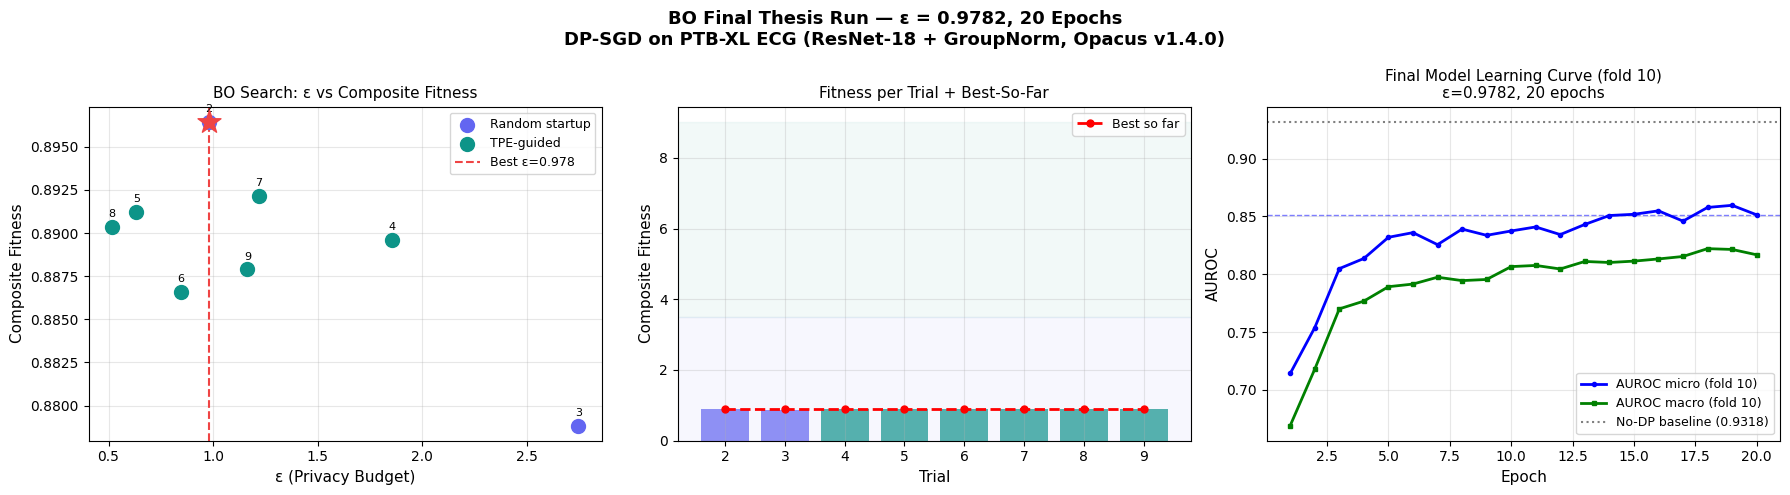

Plot saved: /kaggle/working/bo_final_results_60_40/bo_final_results.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'BO Final Thesis Run — ε = {best_epsilon:.4f}, {EPOCHS} Epochs\nDP-SGD on PTB-XL ECG (ResNet-18 + GroupNorm, Opacus v1.4.0)',
             fontsize=13, fontweight='bold')

df_plot = pd.DataFrame(trial_log).sort_values('trial')
df_rand = df_plot[df_plot['phase'] == 'random']
df_tpe  = df_plot[df_plot['phase'] == 'TPE-guided']

# Panel 1: BO search — epsilon vs fitness
ax = axes[0]
ax.scatter(df_rand['epsilon'], df_rand['fitness'], color='#6366F1', s=100, label='Random startup', zorder=5)
ax.scatter(df_tpe['epsilon'],  df_tpe['fitness'],  color='#0D9488', s=100, label='TPE-guided',    zorder=5)
for _, row in df_plot.iterrows():
    ax.annotate(f'{int(row["trial"])}', xy=(row['epsilon'], row['fitness']),
                xytext=(0, 7), textcoords='offset points', fontsize=8, ha='center')
ax.axvline(x=best_epsilon, color='#EF4444', ls='--', lw=1.5, label=f'Best ε={best_epsilon:.3f}')
ax.scatter([best_epsilon], [best_fitness], marker='*', color='#EF4444', s=300, zorder=6)
ax.set_xlabel('ε (Privacy Budget)', fontsize=11)
ax.set_ylabel('Composite Fitness', fontsize=11)
ax.set_title('BO Search: ε vs Composite Fitness', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 2: convergence during search
ax2 = axes[1]
running_best = [max(df_plot['fitness'].tolist()[:i+1]) for i in range(len(df_plot))]
ax2.bar(df_plot['trial'], df_plot['fitness'], color=['#6366F1' if p=='random' else '#0D9488' for p in df_plot['phase']], alpha=0.7)
ax2.plot(df_plot['trial'], running_best, 'r--o', lw=2, ms=5, label='Best so far')
ax2.axhspan(0, N_STARTUP+0.5, alpha=0.05, color='#6366F1')
ax2.axhspan(N_STARTUP+0.5, N_TRIALS+1, alpha=0.05, color='#0D9488')
ax2.set_xlabel('Trial', fontsize=11)
ax2.set_ylabel('Composite Fitness', fontsize=11)
ax2.set_title('Fitness per Trial + Best-So-Far', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# Panel 3: final model learning curve on fold 10
ax3 = axes[2]
ep_df = pd.DataFrame(epoch_log)
ax3.plot(ep_df['epoch'], ep_df['auroc_micro'], 'b-o', ms=3, lw=2, label='AUROC micro (fold 10)')
ax3.plot(ep_df['epoch'], ep_df['auroc_macro'], 'g-s', ms=3, lw=2, label='AUROC macro (fold 10)')
ax3.axhline(y=BASELINE_AUROC, color='gray', ls=':', lw=1.5, label=f'No-DP baseline ({BASELINE_AUROC})')
ax3.axhline(y=final_auroc_micro, color='blue', ls='--', lw=1, alpha=0.5)
ax3.set_xlabel('Epoch', fontsize=11)
ax3.set_ylabel('AUROC', fontsize=11)
ax3.set_title(f'Final Model Learning Curve (fold 10)\nε={best_epsilon:.4f}, {EPOCHS} epochs', fontsize=11)
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'bo_final_results.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved: {plot_path}')

## Cell 10 — Full Summary for Thesis

In [16]:
print('='*65)
print(' COMPLETE THESIS SUMMARY — BO FINAL RUN')
print('='*65)
print()
print('── Search Phase (Fold 9 Validation) ─────────────────────────')
print(f'  Method          : Bayesian Optimisation (Optuna TPE)')
print(f'  Epochs/trial    : {EPOCHS}')
print(f'  Trials          : {N_TRIALS} ({N_STARTUP} random + {N_TRIALS - N_STARTUP} TPE-guided)')
print(f'  Search range    : ε ∈ [{EPS_MIN}, {EPS_MAX}]')
print(f'  Best ε found    : {best_epsilon:.4f}')
print(f'  Val AUROC (f9)  : {best_auroc:.4f}')
print(f'  Composite fit.  : {best_fitness:.4f}')
print(f'  Search time     : {total_search_min:.1f} min')
print()
print('── Final Evaluation (Fold 10 — Standard Test Set) ───────────')
print(f'  ε (target)      : {best_epsilon:.4f}')
print(f'  ε (achieved)    : {final_eps:.4f}')
print(f'  δ               : {DELTA}')
print(f'  Epochs          : {EPOCHS}')
print(f'  AUROC macro     : {final_auroc_macro:.4f}')
print(f'  AUROC micro     : {final_auroc_micro:.4f}   ← report this in thesis')
print(f'  No-DP baseline  : {BASELINE_AUROC:.4f}')
print(f'  Privacy cost    : {(BASELINE_AUROC - final_auroc_micro) * 100:.2f}% AUROC reduction')
print(f'  Composite fit.  : {final_fitness:.4f}')
print(f'  Privacy score   : {privacy_score:.4f}')
print()
print('── Consensus Check ──────────────────────────────────────────')
print(f'  BO final ε      : {best_epsilon:.4f}')
print(f'  Exploratory BO  : {PREV_BO_EPS}')
print(f'  Consensus (5 methods): {CONSENSUS_EPS}')
print(f'  Distance from consensus: {abs(best_epsilon - CONSENSUS_EPS):.4f} ε units')
print()
print('── Thesis Statement ─────────────────────────────────────────')
print(f'  "Using Bayesian Optimisation (TPE) over {N_TRIALS} trials with')
print(f'  {EPOCHS} epochs per evaluation, we identified ε = {best_epsilon:.2f} as the')
print(f'  optimal privacy budget. The final DP-SGD model trained at this')
print(f'  epsilon achieves AUROC = {final_auroc_micro:.4f} on the standard PTB-XL')
print(f'  test fold (fold 10), representing a {(BASELINE_AUROC - final_auroc_micro)*100:.2f}%')
print(f'  reduction from the no-DP baseline (AUROC = {BASELINE_AUROC}), with a')
print(f'  formal privacy guarantee of (ε={final_eps:.2f}, δ={DELTA})."')
print('='*65)

 COMPLETE THESIS SUMMARY — BO FINAL RUN

── Search Phase (Fold 9 Validation) ─────────────────────────
  Method          : Bayesian Optimisation (Optuna TPE)
  Epochs/trial    : 20
  Trials          : 8 (3 random + 5 TPE-guided)
  Search range    : ε ∈ [0.5, 3.0]
  Best ε found    : 0.9782
  Val AUROC (f9)  : 0.8600
  Composite fit.  : 0.8964
  Search time     : 161.6 min

── Final Evaluation (Fold 10 — Standard Test Set) ───────────
  ε (target)      : 0.9782
  ε (achieved)    : 0.9741
  δ               : 1e-05
  Epochs          : 20
  AUROC macro     : 0.8168
  AUROC micro     : 0.8513   ← report this in thesis
  No-DP baseline  : 0.9318
  Privacy cost    : 8.05% AUROC reduction
  Composite fit.  : 0.8912
  Privacy score   : 0.9511

── Consensus Check ──────────────────────────────────────────
  BO final ε      : 0.9782
  Exploratory BO  : 0.8056
  Consensus (5 methods): 0.87
  Distance from consensus: 0.1082 ε units

── Thesis Statement ─────────────────────────────────────────
  "U